In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
# ==========================================
# 2. DEFINE FILE PATHS
# ==========================================

BASE_PATH = "/content/drive/MyDrive/credit_risk/"

TRAIN_PATH = BASE_PATH + "train.csv"
TEST_PATH = BASE_PATH + "test.csv"
SAMPLE_PATH = BASE_PATH + "sample_submission.csv"

In [68]:
# ==========================================
# 3. IMPORT LIBRARIES
# ==========================================

import numpy as np
import pandas as pd
import os
import random
import gc

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings("ignore")

In [69]:
# ==========================================
# 4. SET RANDOM SEED
# ==========================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(42)

In [70]:
# ==========================================
# 5. LOAD DATA
# ==========================================

print("Loading datasets...")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Sample Submission Shape:", sample_submission.shape)

Loading datasets...
Train Shape: (246008, 122)
Test Shape: (61503, 121)
Sample Submission Shape: (61503, 2)


In [71]:
# ==========================================
# 6. BASIC DATA CHECKS
# ==========================================

print("\nColumns in Train:")
print(train.columns[:10])

print("\nTarget Distribution:")
print(train['TARGET'].value_counts())
print(train['TARGET'].value_counts(normalize=True))


Columns in Train:
Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY'],
      dtype='object')

Target Distribution:
TARGET
0    226148
1     19860
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [72]:
# ==========================================
# 7. MEMORY OPTIMIZATION FUNCTION
# ==========================================

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory usage before: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            df[col] = pd.to_numeric(df[col], downcast='float')
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory usage after: {end_mem:.2f} MB")
    print(f"Reduced by {(start_mem - end_mem)/start_mem * 100:.1f}%")

    return df

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

Memory usage before: 228.98 MB
Memory usage after: 104.17 MB
Reduced by 54.5%
Memory usage before: 56.78 MB
Memory usage after: 25.81 MB
Reduced by 54.5%


In [73]:
# ==========================================
# 8. CHECK TRAIN & TEST CONSISTENCY
# ==========================================

print("Columns difference between train and test:")

train_cols = set(train.columns)
test_cols = set(test.columns)

print("In train but not in test:", train_cols - test_cols)
print("In test but not in train:", test_cols - train_cols)

Columns difference between train and test:
In train but not in test: {'TARGET'}
In test but not in train: set()


In [74]:
# ==========================================
# 9. SPLIT FEATURES & TARGET
# ==========================================

TARGET = 'TARGET'
ID_COL = 'SK_ID_CURR'

X = train.drop(columns=[TARGET])
y = train[TARGET]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (246008, 121)
Target shape: (246008,)


In [75]:
# ==========================================
# 10. CHECK MISSING VALUES
# ==========================================

missing_percent = train.isnull().mean().sort_values(ascending=False)
print(missing_percent.head(10))

COMMONAREA_AVG              0.698396
COMMONAREA_MODE             0.698396
COMMONAREA_MEDI             0.698396
NONLIVINGAPARTMENTS_MEDI    0.693998
NONLIVINGAPARTMENTS_MODE    0.693998
NONLIVINGAPARTMENTS_AVG     0.693998
FONDKAPREMONT_MODE          0.683779
LIVINGAPARTMENTS_AVG        0.683388
LIVINGAPARTMENTS_MEDI       0.683388
LIVINGAPARTMENTS_MODE       0.683388
dtype: float64


In [76]:
# ==========================================
# 1. BASIC DATA OVERVIEW
# ==========================================

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain Info:")
display(train.info())

print("\nFirst 5 rows:")
display(train.head())

Train shape: (246008, 122)
Test shape: (61503, 121)

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246008 entries, 0 to 246007
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: category(16), float32(105), float64(1)
memory usage: 104.2 MB


None


First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,310536.0,0.0,Cash loans,F,N,N,2.0,90000.0,227520.0,13189.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,365516.0,0.0,Cash loans,M,Y,Y,0.0,90000.0,161730.0,13095.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,242055.0,1.0,Cash loans,M,N,Y,0.0,135000.0,728847.0,26307.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0
3,454894.0,1.0,Cash loans,M,N,N,0.0,135000.0,474183.0,34636.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
4,448321.0,0.0,Cash loans,F,N,Y,0.0,180000.0,254700.0,27558.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


Target Counts:
TARGET
0.0    226148
1.0     19860
Name: count, dtype: int64

Target Percentage:
TARGET
0.0    0.919271
1.0    0.080729
Name: proportion, dtype: float64


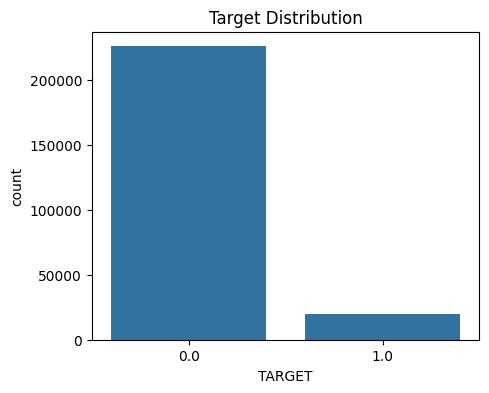

In [77]:
# ==========================================
# 2. TARGET DISTRIBUTION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

print("Target Counts:")
print(train['TARGET'].value_counts())

print("\nTarget Percentage:")
print(train['TARGET'].value_counts(normalize=True))

plt.figure(figsize=(5,4))
sns.countplot(x='TARGET', data=train)
plt.title("Target Distribution")
plt.show()

In [78]:
# ==========================================
# 3. MISSING VALUE ANALYSIS
# ==========================================

missing_percent = train.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("Top 20 columns with highest missing %:")
display(missing_percent.head(20))

Top 20 columns with highest missing %:


,0
COMMONAREA_AVG,69.839599
COMMONAREA_MODE,69.839599
COMMONAREA_MEDI,69.839599
NONLIVINGAPARTMENTS_MEDI,69.399776
NONLIVINGAPARTMENTS_MODE,69.399776
NONLIVINGAPARTMENTS_AVG,69.399776
FONDKAPREMONT_MODE,68.377858
LIVINGAPARTMENTS_AVG,68.338835
LIVINGAPARTMENTS_MEDI,68.338835
LIVINGAPARTMENTS_MODE,68.338835


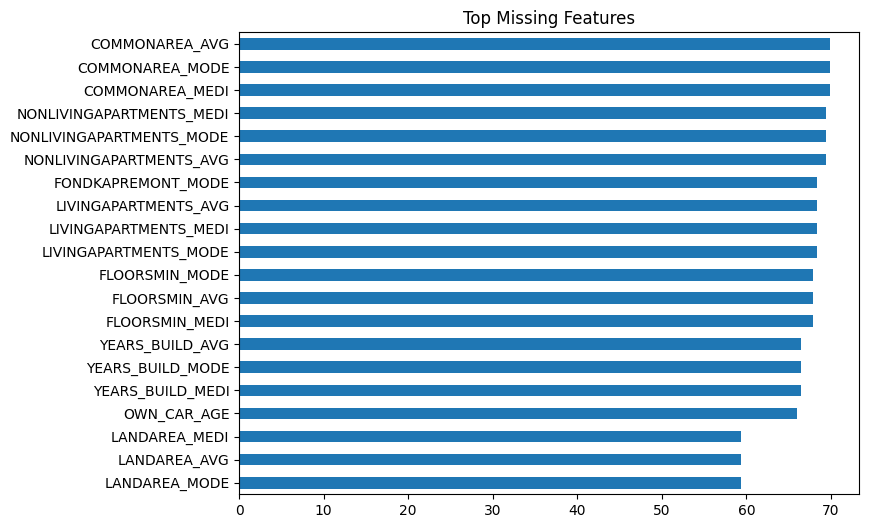

In [79]:
plt.figure(figsize=(8,6))
missing_percent.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Missing Features")
plt.show()

In [80]:
# ==========================================
# 5. CATEGORICAL FEATURES
# ==========================================

cat_cols = train.select_dtypes(include=['object']).columns

print("Number of Categorical Columns:", len(cat_cols))
print(cat_cols)

Number of Categorical Columns: 0
Index([], dtype='object')


In [81]:
for col in cat_cols:
    print(f"\n{col}")
    print(train[col].value_counts().head())

In [82]:
print(train.dtypes.value_counts())

float32     105
category      2
category      1
category      1
float64       1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


In [83]:
train.select_dtypes(include=np.number).head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,310536.0,0.0,2.0,90000.0,227520.0,13189.5,180000.0,0.008230,-12298.0,-946.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,365516.0,0.0,0.0,90000.0,161730.0,13095.0,135000.0,0.003069,-15375.0,-92.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,242055.0,1.0,0.0,135000.0,728847.0,26307.0,553500.0,0.020713,-19307.0,-1646.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0
3,454894.0,1.0,0.0,135000.0,474183.0,34636.5,391500.0,0.011703,-17791.0,-1651.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
4,448321.0,0.0,0.0,180000.0,254700.0,27558.0,225000.0,0.006629,-8486.0,-977.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
# ==========================================
# 6. CORRELATION WITH TARGET
# ==========================================

import numpy as np

# Select only numeric columns
num_cols = train.select_dtypes(include=np.number).columns

corr_matrix = train[num_cols].corr()

target_corr = corr_matrix['TARGET'].sort_values(ascending=False)

print("Top Positive Correlations:")
display(target_corr.head(10))

print("\nTop Negative Correlations:")
display(target_corr.tail(10))

Top Positive Correlations:


,TARGET
TARGET,1.000000
DAYS_BIRTH,0.079467
REGION_RATING_CLIENT_W_CITY,0.061283
REGION_RATING_CLIENT,0.058946
DAYS_LAST_PHONE_CHANGE,0.053795
REG_CITY_NOT_WORK_CITY,0.051666
DAYS_ID_PUBLISH,0.049582
FLAG_EMP_PHONE,0.046407
REG_CITY_NOT_LIVE_CITY,0.045654
FLAG_DOCUMENT_3,0.044299



Top Negative Correlations:


,TARGET
ELEVATORS_AVG,-0.034463
REGION_POPULATION_RELATIVE,-0.037166
AMT_GOODS_PRICE,-0.039895
FLOORSMAX_MODE,-0.042673
FLOORSMAX_MEDI,-0.043457
FLOORSMAX_AVG,-0.043707
DAYS_EMPLOYED,-0.045355
EXT_SOURCE_1,-0.155362
EXT_SOURCE_2,-0.159593
EXT_SOURCE_3,-0.178845


In [85]:
# ==========================================
# DATA CLEANING - COMPLETE BLOCK
# ==========================================

import numpy as np
import pandas as pd

print("Starting Data Cleaning...\n")

# -------------------------------
# 1. Remove Duplicates
# -------------------------------
print("Duplicates in train:", train.duplicated().sum())
train = train.drop_duplicates()

print("Duplicates removed.\n")


# -------------------------------
# 2. Fix Known Data Issues
# -------------------------------
# DAYS_EMPLOYED has strange value 365243 (means missing)
for df in [train, test]:
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

print("Fixed DAYS_EMPLOYED anomalies.\n")


# -------------------------------
# 3. Drop Columns with Very High Missing (>65%)
# -------------------------------
missing_percent = train.isnull().mean()

high_missing_cols = missing_percent[missing_percent > 0.65].index.tolist()

# Avoid dropping TARGET
if 'TARGET' in high_missing_cols:
    high_missing_cols.remove('TARGET')

train = train.drop(columns=high_missing_cols)
test = test.drop(columns=high_missing_cols)

print(f"Dropped {len(high_missing_cols)} high-missing columns.\n")


# -------------------------------
# 4. Add Missing Value Flags
# -------------------------------
for col in train.columns:
    if train[col].isnull().sum() > 0:
        train[col + "_MISSING"] = train[col].isnull().astype(int)
        if col in test.columns:
            test[col + "_MISSING"] = test[col].isnull().astype(int)

print("Added missing indicator columns.\n")


# -------------------------------
# 5. Impute Missing Values
# -------------------------------
num_cols = train.select_dtypes(include=np.number).columns.tolist()

# Remove TARGET from numeric imputation
if 'TARGET' in num_cols:
    num_cols.remove('TARGET')

for col in num_cols:
    median_value = train[col].median()
    train[col] = train[col].fillna(median_value)
    if col in test.columns:
        test[col] = test[col].fillna(median_value)

print("Missing values imputed using median.\n")


# -------------------------------
# 6. Final Consistency Check
# -------------------------------
train_cols = set(train.columns)
test_cols = set(test.columns)

# Ensure TARGET only exists in train
extra_in_train = train_cols - test_cols
extra_in_test = test_cols - train_cols

print("Columns in train but not in test:", extra_in_train)
print("Columns in test but not in train:", extra_in_test)

print("\nFinal Train Shape:", train.shape)
print("Final Test Shape:", test.shape)

print("\nData Cleaning Completed Successfully.")

Starting Data Cleaning...

Duplicates in train: 0
Duplicates removed.

Fixed DAYS_EMPLOYED anomalies.

Dropped 17 high-missing columns.

Added missing indicator columns.

Missing values imputed using median.

Columns in train but not in test: {'TARGET'}
Columns in test but not in train: set()

Final Train Shape: (246008, 156)
Final Test Shape: (61503, 155)

Data Cleaning Completed Successfully.


In [86]:
# ==========================================
# AGGRESSIVE LEADERBOARD-GRADE FEATURE ENGINEERING
# ==========================================

import numpy as np
import pandas as pd
import gc

print("Starting Aggressive Feature Engineering...\n")

# Keep ID and TARGET safe
TARGET = 'TARGET'
ID_COL = 'SK_ID_CURR'

# Work on both train & test together safely (no leakage because no TARGET used)
train_len = len(train)
full = pd.concat([train.drop(columns=[TARGET]), test], axis=0)

print("Combined dataset shape:", full.shape)

# =====================================================
# 1️⃣ FINANCIAL RATIO FEATURES (VERY POWERFUL)
# =====================================================

full['CREDIT_INCOME_RATIO'] = full['AMT_CREDIT'] / (full['AMT_INCOME_TOTAL'] + 1)
full['ANNUITY_INCOME_RATIO'] = full['AMT_ANNUITY'] / (full['AMT_INCOME_TOTAL'] + 1)
full['CREDIT_TERM'] = full['AMT_CREDIT'] / (full['AMT_ANNUITY'] + 1)
full['GOODS_CREDIT_RATIO'] = full['AMT_GOODS_PRICE'] / (full['AMT_CREDIT'] + 1)

# =====================================================
# 2️⃣ AGE & STABILITY FEATURES
# =====================================================

full['AGE_YEARS'] = -full['DAYS_BIRTH'] / 365
full['EMPLOYED_YEARS'] = -full['DAYS_EMPLOYED'] / 365
full['EMPLOYED_PERCENT'] = full['EMPLOYED_YEARS'] / (full['AGE_YEARS'] + 1)

full['DAYS_REGISTRATION_PERC'] = full['DAYS_REGISTRATION'] / (full['DAYS_BIRTH'] + 1)
full['DAYS_ID_PUBLISH_PERC'] = full['DAYS_ID_PUBLISH'] / (full['DAYS_BIRTH'] + 1)

# ==========================================
# STRONG EXT_SOURCE ENGINEERING (FIXED)
# ==========================================

for df in [train, test]:

    # Median impute EXT first
    for col in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']:
        df[col].fillna(df[col].median(), inplace=True)

    df['EXT_MEAN'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
    df['EXT_STD'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
    df['EXT_MIN'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)
    df['EXT_MAX'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].max(axis=1)
    df['EXT_PRODUCT'] = (
        df['EXT_SOURCE_1'] *
        df['EXT_SOURCE_2'] *
        df['EXT_SOURCE_3']
    )

# =====================================================
# 4️⃣ DOCUMENT COUNT FEATURES
# =====================================================

doc_cols = [col for col in full.columns if 'FLAG_DOCUMENT' in col]
full['DOC_COUNT'] = full[doc_cols].sum(axis=1)

# =====================================================
# 5️⃣ LIVE/WORK CITY FLAGS
# =====================================================

live_work_cols = [
    'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY'
]

for col in live_work_cols:
    if col in full.columns:
        full[col] = full[col].astype(float)

full['CITY_MISMATCH_COUNT'] = full[live_work_cols].sum(axis=1)

# =====================================================
# 6️⃣ INCOME PER FAMILY MEMBER
# =====================================================

full['INCOME_PER_PERSON'] = full['AMT_INCOME_TOTAL'] / (full['CNT_FAM_MEMBERS'] + 1)

# =====================================================
# 7️⃣ LOG TRANSFORM SKEWED FEATURES
# =====================================================

skew_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

for col in skew_cols:
    full[col + "_LOG"] = np.log1p(full[col])

# =====================================================
# 8️⃣ INTERACTION FEATURES
# =====================================================

full['CREDIT_PER_PERSON'] = full['AMT_CREDIT'] / (full['CNT_FAM_MEMBERS'] + 1)
full['ANNUITY_PER_PERSON'] = full['AMT_ANNUITY'] / (full['CNT_FAM_MEMBERS'] + 1)

# =====================================================
# 9️⃣ BINNING AGE GROUPS
# =====================================================

full['AGE_BIN'] = pd.cut(
    full['AGE_YEARS'],
    bins=[20,30,40,50,60,100],
    labels=[0,1,2,3,4]
).astype(float)

# =====================================================
# 🔟 SAFE CLEANING OF INF & NaN
# =====================================================

full.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill numeric columns only
num_cols = full.select_dtypes(include=np.number).columns
full[num_cols] = full[num_cols].fillna(0)

# Fill categorical columns with mode
cat_cols = full.select_dtypes(include='category').columns

for col in cat_cols:
    if full[col].isnull().sum() > 0:
        full[col] = full[col].fillna(full[col].mode()[0])

# =====================================================
# SPLIT BACK INTO TRAIN & TEST
# =====================================================

train_fe = full.iloc[:train_len].copy()
test_fe = full.iloc[train_len:].copy()

# Add TARGET back safely
train_fe[TARGET] = train[TARGET].values

print("\nFeature Engineering Completed.")
print("New Train Shape:", train_fe.shape)
print("New Test Shape:", test_fe.shape)

# Free memory
del full
gc.collect()

Starting Aggressive Feature Engineering...

Combined dataset shape: (307511, 155)

Feature Engineering Completed.
New Train Shape: (246008, 174)
New Test Shape: (61503, 173)


7698

In [87]:
# ==========================================
# REMOVE WEAK NOISY FEATURES
# ==========================================

doc_cols = [col for col in train.columns if "FLAG_DOCUMENT" in col]

train.drop(columns=doc_cols, inplace=True)
test.drop(columns=doc_cols, inplace=True)

print("Dropped document flag columns:", len(doc_cols))

Dropped document flag columns: 20


In [88]:
# ==========================================
# HANDLE CLASS IMBALANCE (PROFESSIONAL WAY)
# ==========================================

import numpy as np

print("Handling Class Imbalance...\n")

TARGET = 'TARGET'
ID_COL = 'SK_ID_CURR'

# -----------------------------
# 1️⃣ Separate Features & Target
# -----------------------------
X = train.drop(columns=[TARGET])
y = train[TARGET]

X_test = test.copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# -----------------------------
# 2️⃣ Check Class Distribution
# -----------------------------
class_counts = y.value_counts()
negative = class_counts[0]
positive = class_counts[1]

print("\nClass Distribution:")
print(class_counts)

print("\nDefault Percentage:", positive / len(y))

# -----------------------------
# 3️⃣ Compute scale_pos_weight
# -----------------------------
# Formula: negative / positive

scale_pos_weight = negative / positive

print("\nCalculated scale_pos_weight:", scale_pos_weight)

# -----------------------------
# 4️⃣ Optional: Verify Stratified KFold Setup
# -----------------------------
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\nStratifiedKFold initialized successfully.")

print("\nClass imbalance handling setup complete.")

Handling Class Imbalance...

Feature matrix shape: (246008, 140)
Target shape: (246008,)

Class Distribution:
TARGET
0.0    226148
1.0     19860
Name: count, dtype: int64

Default Percentage: 0.08072908198107379

Calculated scale_pos_weight: 11.38710976837865

StratifiedKFold initialized successfully.

Class imbalance handling setup complete.


In [89]:
# ==========================================
# CROSS VALIDATION SETUP (PROFESSIONAL)
# ==========================================

import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("Setting up Cross Validation...\n")

TARGET = 'TARGET'
ID_COL = 'SK_ID_CURR'

# -----------------------------
# 1️⃣ Prepare Final Modeling Data
# -----------------------------
X = train.drop(columns=[TARGET])
y = train[TARGET]

X_test = test.copy()

print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

# -----------------------------
# 2️⃣ Initialize Stratified KFold
# -----------------------------
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

print(f"\nUsing {N_SPLITS}-Fold Stratified Cross Validation")

# -----------------------------
# 3️⃣ Prepare OOF & Test Arrays
# -----------------------------
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

print("\nOOF and Test prediction arrays initialized.")

# -----------------------------
# 4️⃣ Verify Fold Distribution (Important)
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    print(f"\nFold {fold+1}")
    print("Train default rate:", y_train_fold.mean())
    print("Valid default rate:", y_val_fold.mean())

print("\nCross-validation setup completed successfully.")

Setting up Cross Validation...

Train shape: (246008, 140)
Test shape: (61503, 140)

Using 5-Fold Stratified Cross Validation

OOF and Test prediction arrays initialized.

Fold 1
Train default rate: 0.080729246
Valid default rate: 0.08072843

Fold 2
Train default rate: 0.080729246
Valid default rate: 0.08072843

Fold 3
Train default rate: 0.080729246
Valid default rate: 0.08072843

Fold 4
Train default rate: 0.08072884
Valid default rate: 0.080730066

Fold 5
Train default rate: 0.08072884
Valid default rate: 0.080730066

Cross-validation setup completed successfully.


In [90]:
!pip install catboost

In [91]:
!pip install lightgbm

In [92]:
# ==========================================
# LEADERBOARD PUSH LIGHTGBM
# ==========================================

import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import numpy as np
import gc

print("Training Leaderboard-Push LightGBM...\n")

TARGET = "TARGET"

X = train.drop(columns=[TARGET])
y = train[TARGET]
X_test = test.copy()

lgb_oof = np.zeros(len(X))
lgb_test = np.zeros(len(X_test))

lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.025,      # slightly lower
    "num_leaves": 256,           # more expressive
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.05,
    "reg_lambda": 0.05,
    "scale_pos_weight": scale_pos_weight,
    "n_estimators": 8000,
    "random_state": 42,
    "n_jobs": -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\nFold {fold+1}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(200),
            lgb.log_evaluation(300)
        ]
    )

    lgb_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    lgb_test += model.predict_proba(X_test)[:, 1] / skf.n_splits

    gc.collect()

final_auc = roc_auc_score(y, lgb_oof)
print("\nFinal LightGBM CV ROC-AUC:", final_auc)

Training Leaderboard-Push LightGBM...


Fold 1
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.534585 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10319
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 136
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
Training until validation scores don't improve for 200 rounds
[300]	valid_0's auc: 0.748199
Early stopping, best iteration is:
[202]	valid_0's auc: 0.749886

Fold 2
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.154107 seconds.
You can set `force_row_wise=true` to remove the ov

In [96]:
# ==========================================
# FINAL MODEL TRAINING (IMPROVED VERSION)
# ==========================================

import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import gc

print("Starting Final Model Training...\n")

TARGET = "TARGET"

# ---------------------------------------
# Prepare Data
# ---------------------------------------
X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()
X_test = test.copy()

cat_cols = X.select_dtypes(include=['category']).columns.tolist()

# ---------------------------------------
# LIGHTGBM TRAINING (STRONGER)
# ---------------------------------------

print("Training LightGBM...\n")

lgb_oof = np.zeros(len(X))
lgb_test = np.zeros(len(X_test))

lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.02,
    "num_leaves": 128,                 # increased
    "min_child_samples": 30,           # slightly aggressive
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "scale_pos_weight": scale_pos_weight,
    "n_estimators": 10000,
    "random_state": 42,
    "n_jobs": -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\nLightGBM Fold {fold+1}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        categorical_feature=cat_cols,
        callbacks=[
            lgb.early_stopping(200),
            lgb.log_evaluation(300)
        ]
    )

    lgb_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    lgb_test += model.predict_proba(X_test)[:, 1] / skf.n_splits

    gc.collect()

lgb_auc = roc_auc_score(y, lgb_oof)
print("\nLightGBM CV ROC-AUC:", lgb_auc)


# ---------------------------------------
# CATBOOST TRAINING (SAFE VERSION)
# ---------------------------------------

print("\nPreparing data for CatBoost...")

# Use copies so we don't destroy X
X_cb = X.copy()
X_test_cb = X_test.copy()

for col in cat_cols:
    X_cb[col] = X_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

cat_feature_indices = [X_cb.columns.get_loc(col) for col in cat_cols]

print("Training CatBoost...\n")

cat_oof = np.zeros(len(X_cb))
cat_test = np.zeros(len(X_test_cb))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cb, y)):

    print(f"\nCatBoost Fold {fold+1}")

    X_train, X_val = X_cb.iloc[train_idx], X_cb.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=6000,                # slightly stronger
        learning_rate=0.03,
        depth=6,
        eval_metric='AUC',
        random_seed=42,
        verbose=500,
        early_stopping_rounds=200,
        auto_class_weights='Balanced'
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_feature_indices,
        use_best_model=True
    )

    cat_oof[val_idx] = model.predict_proba(X_val)[:, 1]
    cat_test += model.predict_proba(X_test_cb)[:, 1] / skf.n_splits

    gc.collect()

cat_auc = roc_auc_score(y, cat_oof)
print("\nCatBoost CV ROC-AUC:", cat_auc)


# ---------------------------------------
# BLENDING
# ---------------------------------------

print("\nBlending Models...")

final_oof = 0.6 * lgb_oof + 0.4 * cat_oof
final_test = 0.6 * lgb_test + 0.4 * cat_test

final_auc = roc_auc_score(y, final_oof)

print("\nFinal Blended CV ROC-AUC:", final_auc)
print("\nModel Training Completed Successfully.")

Starting Final Model Training...

Training LightGBM...


LightGBM Fold 1
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.457910 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10319
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 136
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
Training until validation scores don't improve for 200 rounds
[300]	valid_0's auc: 0.75255
Early stopping, best iteration is:
[315]	valid_0's auc: 0.752569

LightGBM Fold 2
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.276156 seconds.
You can set `for

In [97]:
print("====================================")
print("MODEL EVALUATION SUMMARY")
print("====================================")
print("LightGBM CV AUC :", lgb_auc)
print("CatBoost CV AUC :", cat_auc)
print("Blended CV AUC  :", final_auc)
print("====================================")

MODEL EVALUATION SUMMARY
LightGBM CV AUC : 0.7541153639175877
CatBoost CV AUC : 0.7582176721476462
Blended CV AUC  : 0.7578254404369151


In [98]:
from sklearn.metrics import classification_report

binary_preds = (final_oof > 0.5).astype(int)

print(classification_report(y, binary_preds))

              precision    recall  f1-score   support

         0.0       0.96      0.75      0.84    226148
         1.0       0.18      0.63      0.28     19860

    accuracy                           0.74    246008
   macro avg       0.57      0.69      0.56    246008
weighted avg       0.90      0.74      0.79    246008



In [99]:
submission = pd.DataFrame({
    "SK_ID_CURR": test["SK_ID_CURR"],
    "TARGET": lgb_test
})

submission.to_csv("submission.csv", index=False)

In [100]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>